# A6 — Holt-Winters (Triple Exponential Smoothing)

In this notebook, we apply **Holt-Winters Exponential Smoothing** to the monthly total passenger series for JFK airport.

## Objective
The goal is to model:
- level,
- trend,
- and seasonality

to improve forecasting performance.

## Why Holt-Winters?

Previous models showed limitations:

- SES → only level
- Holt → level + trend

However, the data clearly contains strong seasonal patterns.

Holt-Winters extends these models by incorporating seasonality, making it more suitable for this dataset.

In [1]:
## Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [2]:
df = pd.read_csv('../data/air-passenger-traffic-per-month-port-authority-of-ny-nj-beginning-1977.csv')

df_jfk = df[df['Airport Code'] == 'JFK']

df_jfk['Date'] = pd.to_datetime(
    df_jfk['Year'].astype(str) + '-' + df_jfk['Month'].astype(str) + '-01'
)

ts = df_jfk.groupby('Date')['Total Passengers'].sum().sort_index()

ts.head()

C:\Users\Merve\AppData\Local\Temp\ipykernel_14056\3268970728.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jfk['Date'] = pd.to_datetime(


Date
1977-01-01    1487588
1977-02-01    1237719
1977-03-01    1450395
1977-04-01    1609159
1977-05-01    1724392
Name: Total Passengers, dtype: int64

In [3]:
model = ExponentialSmoothing(
    ts,
    trend='mul',
    seasonal='mul',
    seasonal_periods=12
)

model_fit = model.fit()


c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Model Fitting 

we fit the Holt-Winters model with multiplicative trend and seasonality.
the model automatically optimizes smoothing parameters for:
-level,
-trend,
- and sesonal components. 

In [4]:
fitted_values = model_fit.fittedvalues
forecast = model_fit.forecast(12)

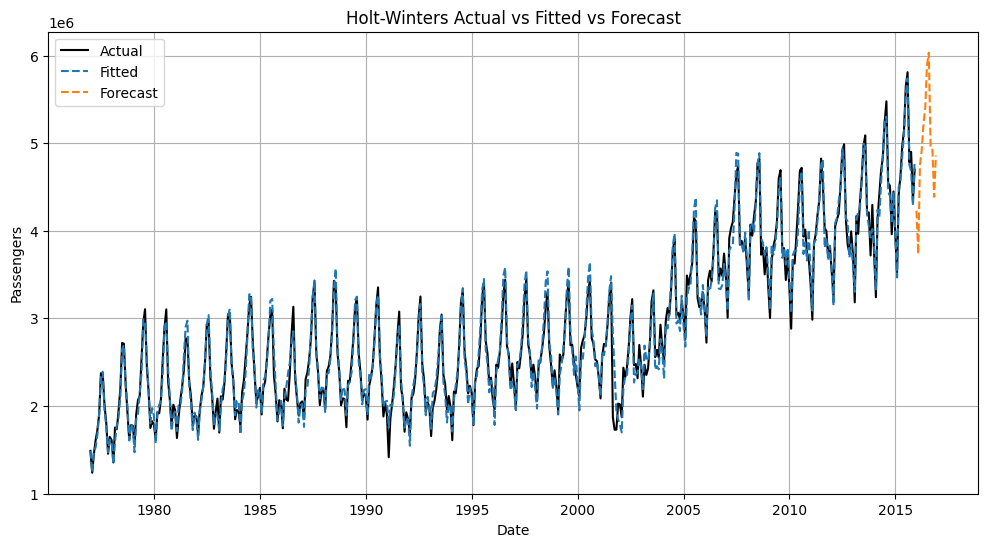

In [5]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual', color='black')
plt.plot(fitted_values, label='Fitted', linestyle='--')
plt.plot(forecast, label='Forecast', linestyle='--')

plt.title('Holt-Winters Actual vs Fitted vs Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')

plt.legend()
plt.grid(True)
plt.show()

## Interpretation

The Holt-Winters model provides a significantly improved fit:

- It captures the upward trend in the data,
- It successfully models seasonal patterns,
- The fitted values closely follow the actual series.

The forecast also reflects both:
- trend,
- and seasonality,

making it much more realistic compared to SES and Holt models.

This confirms that Holt-Winters is the most suitable model for this dataset.

In [6]:
model = ExponentialSmoothing(
    ts,
    trend='add',          # 🔥 change
    seasonal='mul',
    seasonal_periods=12
)

model_fit = model.fit()

fitted_values = model_fit.fittedvalues
forecast = model_fit.forecast(12)

c:\Users\Merve\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Model Adjustment

The initial model used multiplicative trend and seasonality.

However, this resulted in overly aggressive forecasts.

To improve stability:
- the trend component was changed to additive,
- while keeping multiplicative seasonality.

This adjustment produces more realistic and stable forecasts.

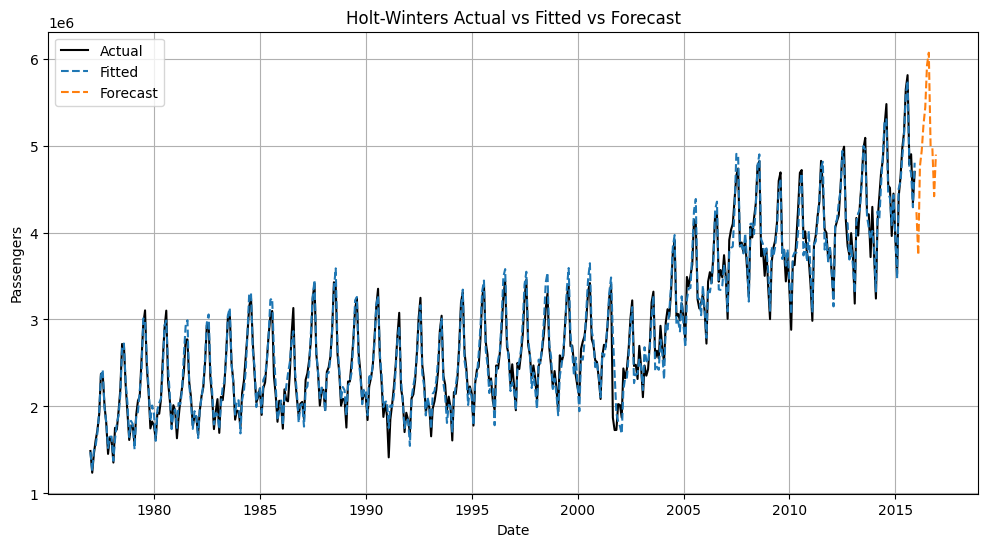

In [7]:
plt.figure(figsize=(12,6))
plt.plot(ts, label='Actual', color='black')
plt.plot(fitted_values, label='Fitted', linestyle='--')
plt.plot(forecast, label='Forecast', linestyle='--')

plt.title('Holt-Winters Actual vs Fitted vs Forecast')
plt.xlabel('Date')
plt.ylabel('Passengers')

plt.legend()
plt.grid(True)
plt.show()